# EDA on Simulated Data

## Goal
Explore simulated dog dataset and understand how different dog features and environmental conditions affect core body temperature (CBT) and heat risk to identify which factors are important for predicting CBT and detecting heat stress.

## Objectives
* Understand dataset structure
* Check for realism in dataset
* Identify outliers and skews 
* Summarize feature distribution
* Calculate feature importance
* Identify feature interactions
* Univariate analysis

## Datasets
* Main Dataset: FullSimDF.csv
* Reference Datasets:
   * breed_traits_long.csv
   * breed_traits_long.csv
   * breed_traits.csv
   * trait_descriptions.csv
   * breed_rank.csv
   * dogs_dataset.csv
   * dogs_dataset_EDA.csv
* Useful information: simulated_features_description.md
   * Gives in-depth description of each feature

In [51]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder # converts labels into numbers
from sklearn.feature_selection import SelectKBest, mutual_info_regression, f_regression, f_classif # for feature importance and interaction

## Understand Dataset Structure
* Check for missing values
* Identify numerical, categorical, and boolean features

### Preview Data and Check for Missing Values

In [52]:
# load simulated dataset
df = pd.read_csv("FullSimDF.csv")
print(f"Rows (Count of Dogs): {df.shape[0]}\nColumns (Number of Features): {df.shape[1]}\n") 
display(df.head()) 

Rows (Count of Dogs): 9335
Columns (Number of Features): 39



,Breed,Age,Weight,Gender,Color,Coat Length,Coat Type,Energy Level,Playfulness Level,is_brachycephalic,...,Hum_Diff,CBT_simulated,is_old,is_overweight,heat_stress_risk,High_humidity_fordogs,prior_heat_related_injury_est,simulated_heat_injury_flag,target2Category,target3Category
0,Rottweiler,7.4,18.2,Female,Gray,Short,Smooth,3.0,4.0,0.0,...,1.73,38.247775,0,0,0,0,0.000,0,0,Normal
1,Poodle,11.3,61.3,Male,Brindle,Long,Curly,4.0,5.0,0.0,...,9.73,39.811340,0,0,0,1,0.022,0,1,Heat Stress
2,Airedale Terrier,10.0,37.5,Male,Merle,Short,Wiry,3.0,3.0,0.0,...,4.71,38.629803,0,0,0,1,0.012,0,0,Normal
3,Havanese,6.5,52.6,Male,Red,Long,Double,3.0,5.0,0.0,...,8.38,39.634108,0,0,0,0,0.002,0,0,Normal
4,Labrador Retriever,5.8,45.4,Female,Black and Tan,Short,Double,5.0,5.0,0.0,...,6.47,39.268502,0,0,0,0,0.022,0,0,Normal


In [53]:
# check for any missing values
if df.isnull().values.any() == False:
    print("No missing values found ✅")
else:
    df.isnull().sum()

No missing values found ✅


### Create Separate Features List

In [54]:
# create summary table
info_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum(),
    "Unique Values": df.nunique()
    
})

# create separate numerical, categorical, and boolean attributes list
numeric_cols = df.select_dtypes(include=["int64","float64"])
numeric_cols = numeric_cols.loc[:, numeric_cols.nunique() > 2].columns.tolist()
categorical_cols = df.select_dtypes(include=["str"])
categorical_cols = categorical_cols.loc[:, categorical_cols.nunique() > 2].columns.tolist()
bool_cols = df.columns[df.nunique() == 2].tolist()

# display each list's attributes and count
print(f"\nCommon Data Type: {info_df["Data Type"].mode()[0]}") # displays the common data type amongst columns
print(f"\nNumeric Attributes: {", ".join(numeric_cols)}") # lists columns that are numeric
print(f"\nNumeric Attributes Count: {len(numeric_cols)}")
print(f"\nCategorical Attributes: {", ".join(categorical_cols)}") # lists columns are that categorical
print(f"\nNumeric Attributes Count: {len(categorical_cols)}")
print(f"\nBoolean Attributes: {", ".join(bool_cols)}") # lists columns that are boolean (0/1 or true/false)
print(f"\nNumeric Attributes Count: {len(bool_cols)}")

# display summary table
info_df


Common Data Type: float64

Numeric Attributes: Age, Weight, Energy Level, Playfulness Level, Sun Exposure, Wind Cooling Effect, Station_Temp, Station_Humidity, Ambient_Temp, Ambient_Humidity, T_device, H_device, breed_wt_mu, breed_wt_sd, ideal_weight, pct_of_ideal, BCS_cont, BCS, Temp_Diff, Hum_Diff, CBT_simulated, prior_heat_related_injury_est

Numeric Attributes Count: 22

Categorical Attributes: Breed, Color, Coat Length, Coat Type, size_category, Season, target3Category

Numeric Attributes Count: 7

Boolean Attributes: Gender, is_brachycephalic, Spayed/Neutered, Indoor/Outdoor, is_old, is_overweight, heat_stress_risk, High_humidity_fordogs, simulated_heat_injury_flag, target2Category

Numeric Attributes Count: 10


,Data Type,Non-null Count,Null Count,Unique Values
Breed,str,9335,0,46
Age,float64,9335,0,256
Weight,float64,9335,0,842
Gender,str,9335,0,2
Color,str,9335,0,16
Coat Length,str,9335,0,3
Coat Type,str,9335,0,6
Energy Level,float64,9335,0,3
Playfulness Level,float64,9335,0,3
is_brachycephalic,float64,9335,0,2


#### Observations
* The simulated dataset contains 39 features, which can be grouped into several categories
* For simplicity and organization, the features have been classified as numerical, categorical, and boolean
   * Boolean attributes are encoded as 0/1 to represent true/false or yes/no values
   * Boolean attributes may also be considered a subset of categorical features
* Of the 39 features, 22 are numerical (e.g., weight and temperature), 7 are categorical (e.g., physical characteristics of the dog), and 10 are boolean (e.g., whether the dog is old)
   * The majority of features are numerical and are derived through calculation

## Check for Realism in Dataset
* Check if any data is flawed or unreasonable
   * Focusing mainly on numeric attributes
* Ensure values are within threshold range
* Identify any outliers or concerning values 

### Weight Information
* Total number of unique breeds
* Count of total dogs for each breed
* Average weight of all dogs in a specific breed
* Weight variation (standard deviation) of all dogs in a specific breed 

In [55]:
# display total unique breed types
total_breeds = df["Breed"].nunique()
print(f"Total Unique Breeds: {total_breeds}\n")

# organize info to display weight info for each breed
breed_wt_info = df.groupby("Breed")["Weight"].agg(["count", "mean", "std"]).reset_index()

# display headers, and format with space and separation lines
print(f"{"Breed Name":<30} | {"Count":<6} | {"Avg Weight":<11} | {"Std Dev":<8}")
print("-" * 70)

# loop through breed statistics to display a formatted summary report
for index, row in breed_wt_info.iterrows():
    # get breed statistics from current row 
    breed = row["Breed"]
    num_dogs = row["count"]
    avg_weight = row["mean"]
    std_weight = row["std"]

    # display breed statistics for current row
    print(f"{breed:<30} | {num_dogs:<6} | {avg_weight:<11.2f} | {std_weight:<8}")

Total Unique Breeds: 46

Breed Name                     | Count  | Avg Weight  | Std Dev 
----------------------------------------------------------------------
Airedale Terrier               | 178    | 31.67       | 13.782987933095903
Akita                          | 152    | 31.70       | 13.42122440584721
Alaskan Malamute               | 189    | 35.06       | 15.973834953747748
Australian Shepherd            | 178    | 31.92       | 14.902328191053577
Basenji                        | 146    | 32.64       | 17.674188297605518
Beagle                         | 191    | 32.56       | 16.256931794114813
Bernese Mountain Dog           | 186    | 35.36       | 18.539624898276344
Bloodhound                     | 201    | 32.98       | 17.198061862919207
Border Collie                  | 358    | 30.57       | 15.990140891516889
Boston Terrier                 | 165    | 34.61       | 18.108690832468465
Boxer                          | 186    | 33.73       | 16.395251658769187
Bull Terrier   

#### Observations
* The dataset includes 46 unique dog breeds, organized alphabetically, with corresponding statistics for average weight and standard deviation for each breed
* There are 9,335 dogs in total, with most breeds containing approximately 170–250 dogs
   * Some breeds vary in size, with counts ranging from about 150 to 400 dogs
* The average weight across breeds is approximately 31–33 kg, with a standard deviation of around 15 kg
* Overall, the dataset appears diverse in terms of breed representation and reasonably realistic in its weight distribution

### Explore Values for Numeric Attributes
* Find min, max, range, and average 
* Search for outliers (like negative values or beyond threshold)
   * Find count for them

In [56]:
# get all numeric cols except prior_heat_related_injury_est since it's not very helpful right now
analyze_cols = [col for col in numeric_cols if col != "prior_heat_related_injury_est"] 

# calculate statistics for each numeric attribute
for col in analyze_cols:
    # get min, max, range, and avg of values in each col
    min_val = df[col].min()
    max_val = df[col].max()
    vals_range = max_val - min_val
    vals_avg = df[col].mean()

    # proper formatting to display statistics 
    print(f"Attribute: {col}")
    print(f"  Min: {min_val:.2f}")
    print(f"  Max: {max_val:.2f}")
    print(f"  Range: {vals_range:.2f}")
    print(f"  Average: {vals_avg:.2f}")
    print("-" * 30) 

Attribute: Age
  Min: -8.60
  Max: 22.30
  Range: 30.90
  Average: 7.40
------------------------------
Attribute: Weight
  Min: -32.00
  Max: 98.20
  Range: 130.20
  Average: 32.18
------------------------------
Attribute: Energy Level
  Min: 3.00
  Max: 5.00
  Range: 2.00
  Average: 3.84
------------------------------
Attribute: Playfulness Level
  Min: 3.00
  Max: 5.00
  Range: 2.00
  Average: 4.03
------------------------------
Attribute: Sun Exposure
  Min: 0.00
  Max: 5.63
  Range: 5.63
  Average: 0.57
------------------------------
Attribute: Wind Cooling Effect
  Min: -1.93
  Max: 0.77
  Range: 2.70
  Average: -0.09
------------------------------
Attribute: Station_Temp
  Min: -3.68
  Max: 49.96
  Range: 53.64
  Average: 24.95
------------------------------
Attribute: Station_Humidity
  Min: 22.23
  Max: 100.00
  Range: 77.77
  Average: 73.74
------------------------------
Attribute: Ambient_Temp
  Min: -2.07
  Max: 49.42
  Range: 51.49
  Average: 23.02
-------------------------

#### Observations
* The purpose of the results is to examine the numerical features for realism and to identify potential outliers
* The features Age, Weight, Ideal Weight, and PCT of Ideal are concerning, as they contain negative minimum values, which are biologically implausible
    * This likely results from the use of a normal distribution in the simulation (e.g., a mean of 10 with a standard deviation of 15 can yield values such as -5)
    * This reflects a contradiction between biological constraints and mathematical modeling, rather than an actual error in the model
    * Data cleaning is necessary to prevent these values from skewing results
* Some temperature-related features include negative values, which are reasonable if the simulation accounts for cold environmental conditions
* The Energy and Playfulness Level features range from 3 to 5, which is unconventional compared to typical scales (e.g., 1–5 or 1–3), but still usable
* Humidity-related features appropriately reach a maximum of 100, as they represent percentages
* The PCT of Ideal and BCS Cont features contain extreme outliers (in the thousands), which are inconsistent with their expected range of approximately 1–9
   * These values should be cleaned to avoid distortion in analysis
* Outliers in BCS Cont may result from rounding or truncation when converting to the integer-based BCS feature
* The CBT Simulated feature appears clean and biologically realistic, with an average core body temperature of approximately 39.13 °C

In [57]:
# identify total count of "outliers" for these attributes 
negative_age = (df["Age"] <= 0).sum()
negative_weight = (df["Weight"] <= 0).sum()
negative_pct = (df["pct_of_ideal"] <= 0).sum()
negative_bcs_cont = (df["BCS_cont"] <= 0).sum()

# display results
print(f"Negative Ages Count: {negative_age}")
print(f"Negative Weight Count: {negative_weight}")
print(f"Negative PCT of Ideal Count: {negative_pct}")
print(f"Negative BCS Count: {negative_bcs_cont}")

Negative Ages Count: 321
Negative Weight Count: 187
Negative PCT of Ideal Count: 398
Negative BCS Count: 273


#### Observations
* Although these features contain negative values, they are not necessarily “incorrect,” but rather reflect a contradiction between biological constraints and mathematical modeling
* These values arise because the model generates data using a mean and standard deviation (e.g., a mean of 10 with a standard deviation of 15 can yield values such as -5)
* Important: The data should be cleaned or adjusted to prevent unrealistic values from affecting the results
   * This can be done by applying a floor or setting appropriate thresholds

## Summary Statistics and Feature Distributions
* Calculate statistical summaries 
* Visualize feature distributions
* Identify outliers and skewed distributions
* Identify imbalanced categories

In [58]:
# summary statistics
df.describe(include='all')

,Breed,Age,Weight,Gender,Color,Coat Length,Coat Type,Energy Level,Playfulness Level,is_brachycephalic,...,Hum_Diff,CBT_simulated,is_old,is_overweight,heat_stress_risk,High_humidity_fordogs,prior_heat_related_injury_est,simulated_heat_injury_flag,target2Category,target3Category
count,9335,9335.000000,9335.000000,9335,9335,9335,9335,9335.000000,9335.000000,9335.000000,...,9335.000000,9335.000000,9335.000000,9335.000000,9335.000000,9335.000000,9335.000000,9335.000000,9335.000000,9335
unique,46,NaN,NaN,2,16,3,6,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Doberman Pinscher,NaN,NaN,Female,Red,Short,Smooth,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal
freq,470,NaN,NaN,4746,634,5087,4289,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8151
mean,NaN,7.399721,32.184821,NaN,NaN,NaN,NaN,3.839100,4.026352,0.170862,...,5.997905,39.130034,0.131441,0.299625,0.495126,0.298232,0.023153,0.023139,0.126834,NaN
std,NaN,4.045858,15.839744,NaN,NaN,NaN,NaN,0.742243,0.753502,0.376409,...,3.527446,0.583020,0.337900,0.458118,0.500003,0.457507,0.027103,0.150352,0.332805,NaN
min,NaN,-8.600000,-32.000000,NaN,NaN,NaN,NaN,3.000000,3.000000,0.000000,...,-0.920000,37.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,4.700000,21.300000,NaN,NaN,NaN,NaN,3.000000,3.000000,0.000000,...,3.150000,38.722669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,7.400000,32.200000,NaN,NaN,NaN,NaN,4.000000,4.000000,0.000000,...,5.640000,39.113383,0.000000,0.000000,0.000000,0.000000,0.012000,0.000000,0.000000,NaN
75%,NaN,10.200000,42.800000,NaN,NaN,NaN,NaN,4.000000,5.000000,0.000000,...,8.270000,39.520726,0.000000,1.000000,1.000000,1.000000,0.042000,0.000000,0.000000,NaN


### Distribution of Numeric Features

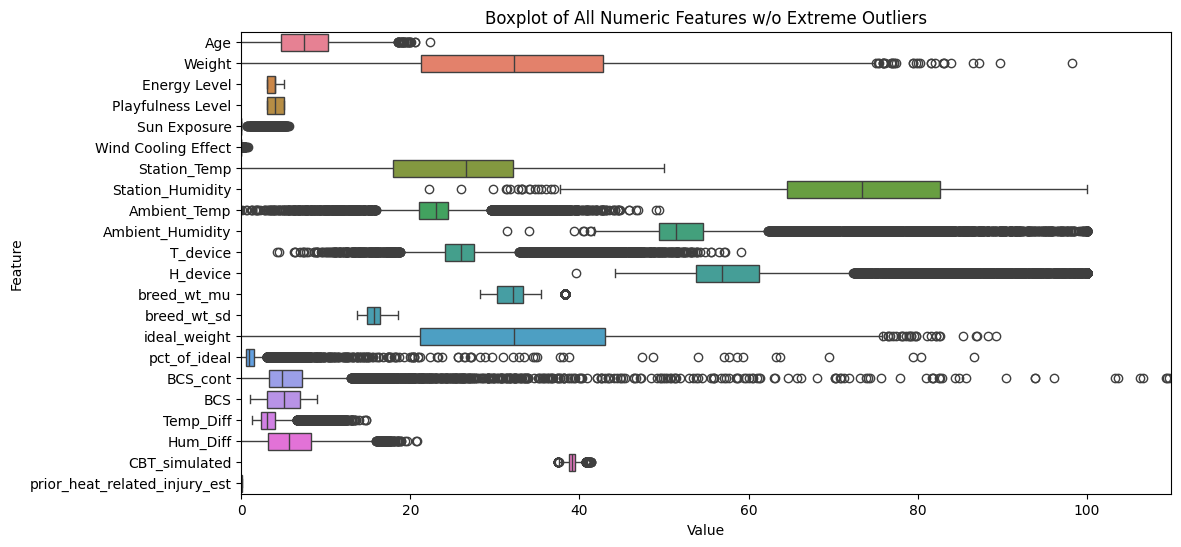

In [59]:
# visualize numeric attributes (w/o extreme outliers)
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols], orient="h")

# plot details
plt.xlim(0,110) 
plt.title("Boxplot of All Numeric Features w/o Extreme Outliers")
plt.xlabel("Value")
plt.ylabel("Feature")
plt.show()

#### Observations 
* Boxplots are used to better visualize the distribution and range of the features
* The boxplot is clipped at 110, which excludes some extreme outliers from the visualization
* Most features exhibit right-skewed distributions
* Features such as Weight and Ideal Weight show wide distributions (larger interquartile ranges), whereas features like Energy Level and Breed Weight Standard Deviation are more tightly clustered, likely due to imposed thresholds
* Some features display high-density outliers, particularly Ambient Temperature and Ambient Humidity
* A clear ceiling at 100 is visible for humidity-related features, consistent with their percentage-based nature
* Features such as Sun Exposure, Wind Cooling Effect, and PCT of Ideal are heavily clustered near 0, suggesting that these values are low for most dogs, with a few higher outliers (especially for PCT of Ideal)
* CBT Simulated has the smallest spread in the boxplot, indicating it is the most stable and controlled variable in the simulation
   * This is reasonable, as it is derived from multiple contributing factors

NOTE: Notable outliers with BCS_cont and pct_of_ideal


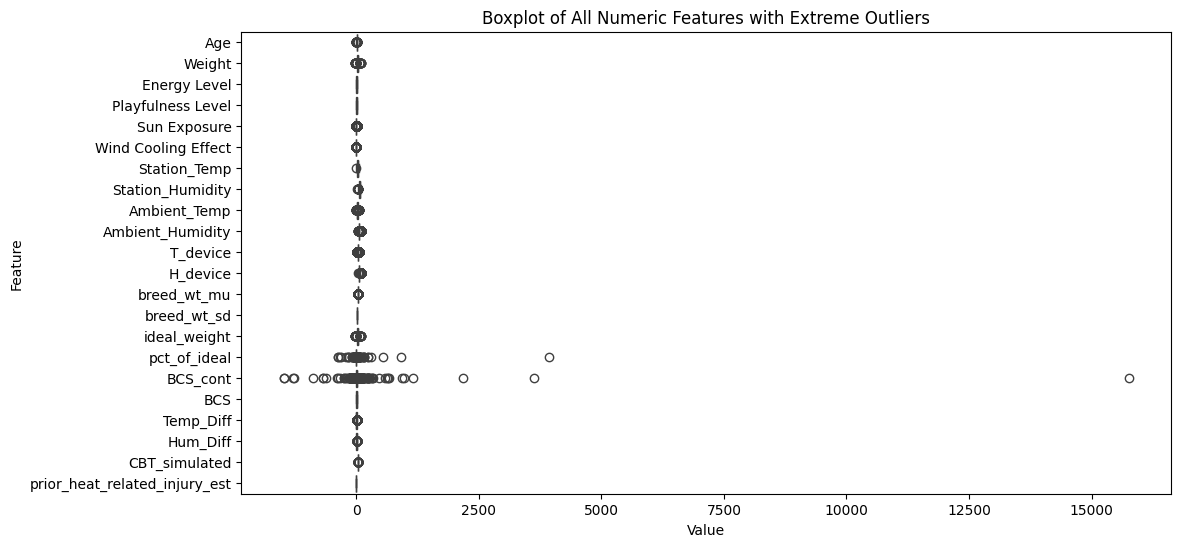

In [60]:
# visualize numeric attributes (w/extreme outliers)
print("NOTE: Notable outliers with BCS_cont and pct_of_ideal")
plt.figure(figsize=(12,6))

# plot details
sns.boxplot(data=df[numeric_cols], orient="h")
plt.title("Boxplot of All Numeric Features with Extreme Outliers")
plt.xlabel("Value")
plt.ylabel("Feature")
plt.show()

#### Observations
* Clear extreme outliers are observed for PCT of Ideal and BCS Cont, consistent with earlier findings
* Most features have values centered in the hundreds, indicating similar overall scales across these attributes

In [61]:
# calculate skewness of numeric attributes
skew_vals = df[numeric_cols].skew().sort_values(ascending=False)
print("Positive value is right skewed and negative value is left skewed\n")
print(skew_vals)

Positive value is right skewed and negative value is left skewed

BCS_cont                         80.023241
pct_of_ideal                     80.023241
Ambient_Humidity                  2.209518
Sun Exposure                      1.910398
H_device                          1.808600
Temp_Diff                         1.754693
T_device                          1.700465
prior_heat_related_injury_est     1.024077
Hum_Diff                          0.706443
breed_wt_mu                       0.479919
breed_wt_sd                       0.467528
Energy Level                      0.267053
Ambient_Temp                      0.240902
BCS                               0.184330
CBT_simulated                     0.179361
Weight                            0.017300
Age                              -0.001701
Station_Humidity                 -0.001717
ideal_weight                     -0.028111
Playfulness Level                -0.043367
Station_Temp                     -0.415622
Wind Cooling Effect            

#### Observations
* Most skewness values are positive, indicating that many features are right-skewed
* BCS Cont and PCT of Ideal have extremely high skewness values (around 80), while most other features have averages near 1, further supporting the presence of extreme outliers
* Most temperature-related features show greater variability, which aligns with the realistic expectation that temperature can vary widely

### Distribution of Categorical Features

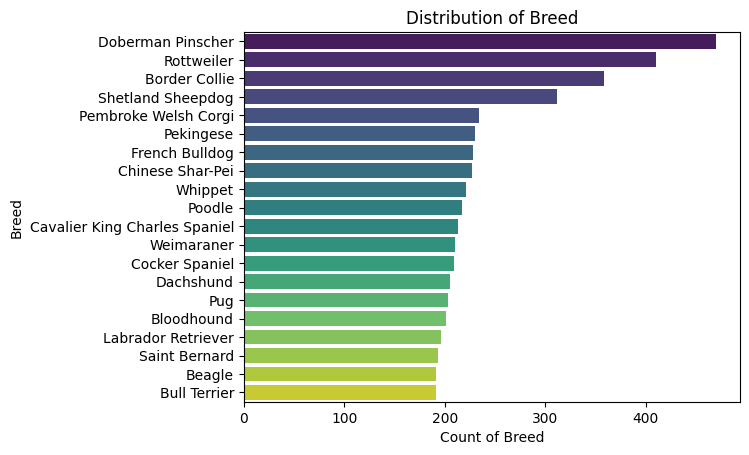

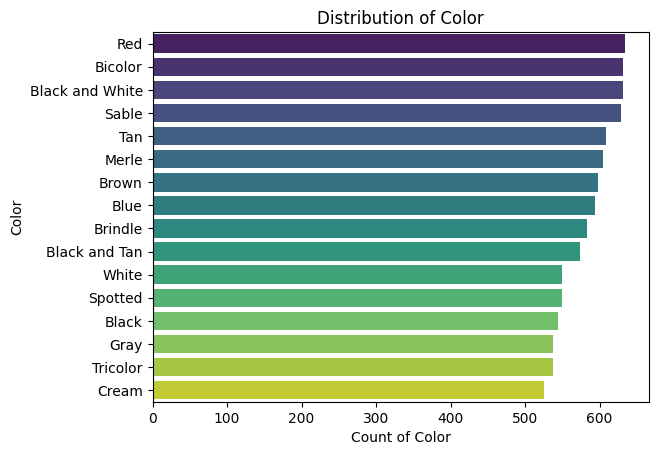

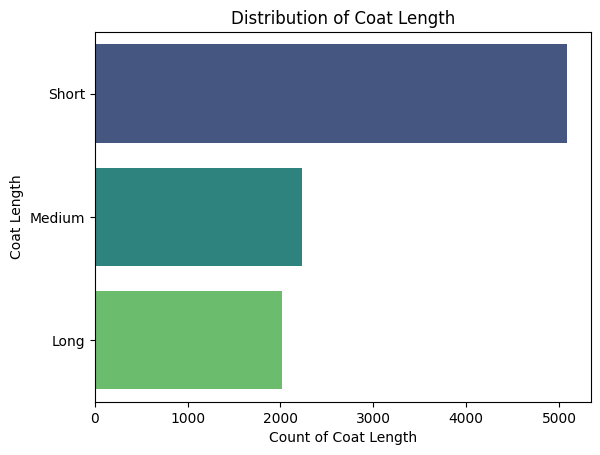

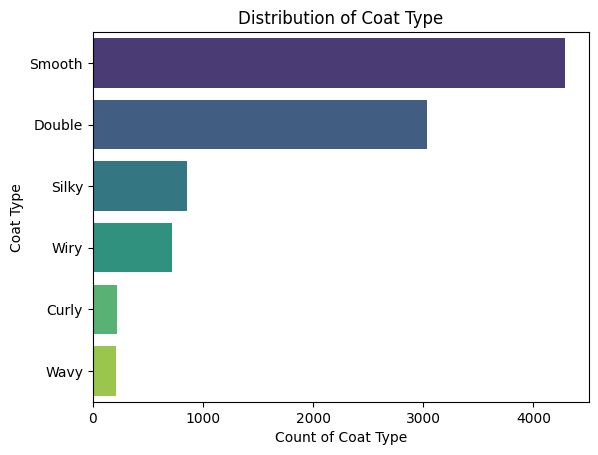

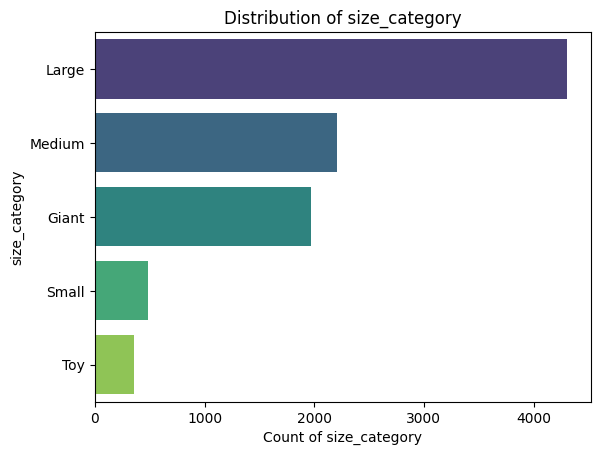

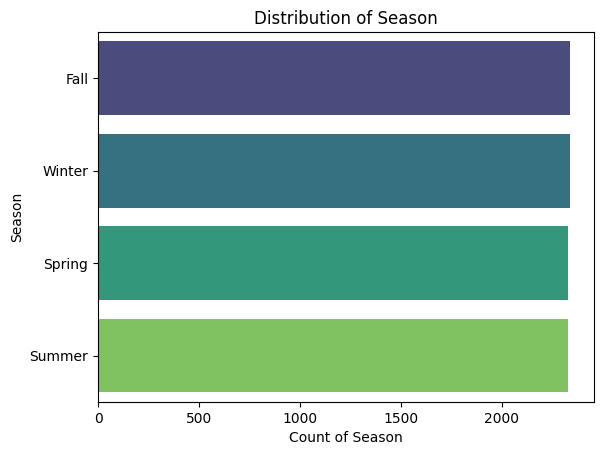

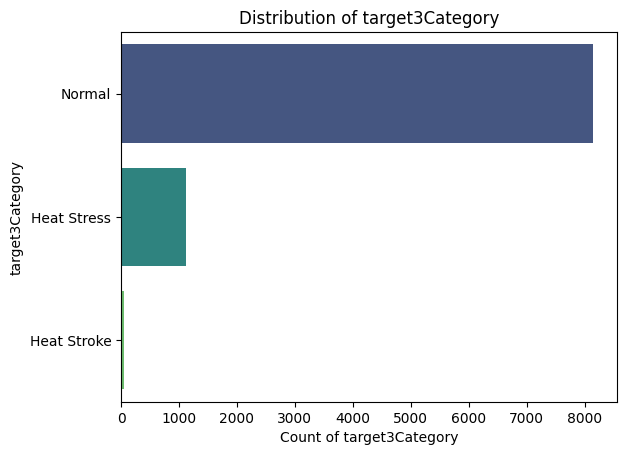

In [62]:
# visualize each categorical attribute's distribution (limited to top 20)
for col in categorical_cols:
    top_20 = df[col].value_counts().head(20).index

    # plot details
    sns.countplot(data=df, y=col, order=top_20, palette="viridis", hue=col, hue_order=top_20, legend=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(f"Count of {col}")
    plt.ylabel(f"{col}")
    plt.show()

#### Observations
* The distribution of categorical attributes is examined to understand which categories are more prevalent
* Breeds such as Doberman Pinscher, Rottweiler, Border Collie, and Shetland Sheepdog have the highest counts (approximately 330–470 dogs), while most other breeds range from about 180–210 dogs
* Coat colors are fairly evenly distributed (around 510–600 dogs per color), with slightly higher counts for red and bicolor coats
* The majority of dogs are large, have short coat lengths, and commonly exhibit smooth or double coat types
* Seasons are evenly distributed, with approximately 2,333 dogs per season (9,335 total divided by 4)
* The simulation primarily consists of normal-condition dogs, with a little over 1,000 cases of heat stress and very few cases of heat stroke

### Distribution of Boolean Features

1 - true
0 - false


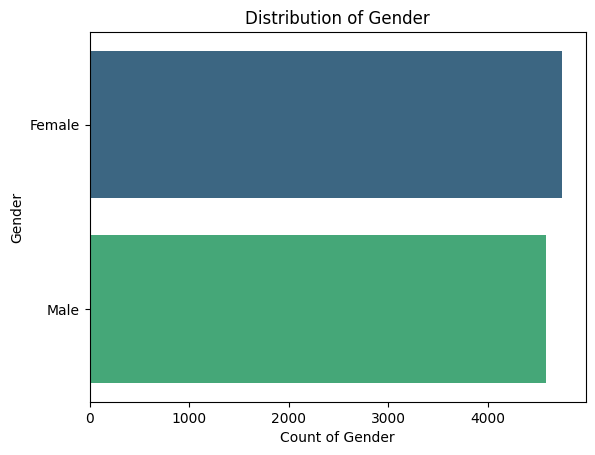

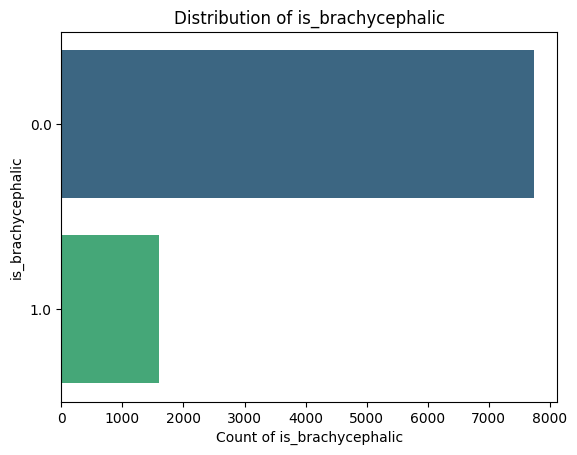

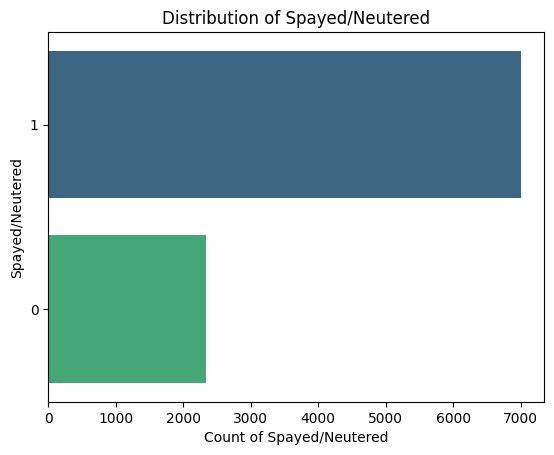

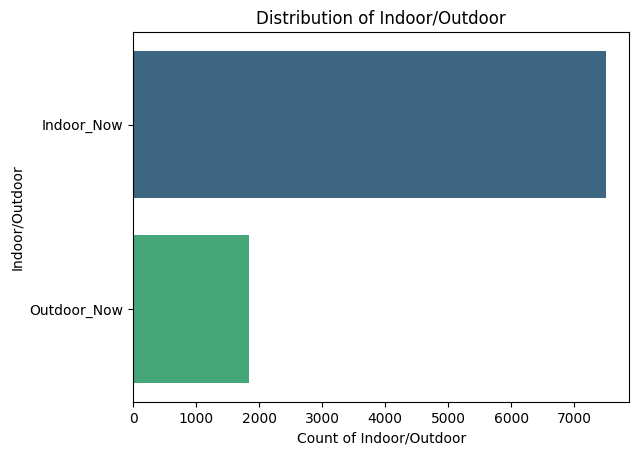

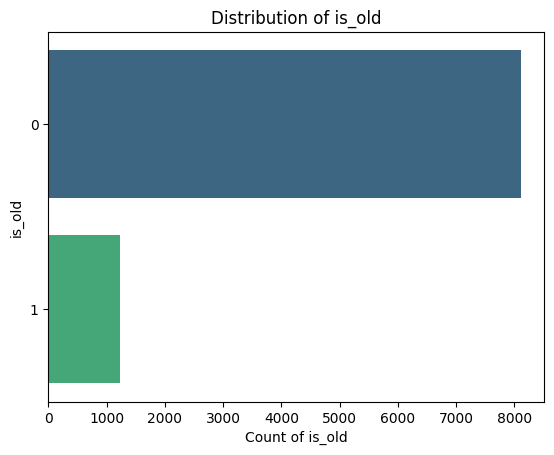

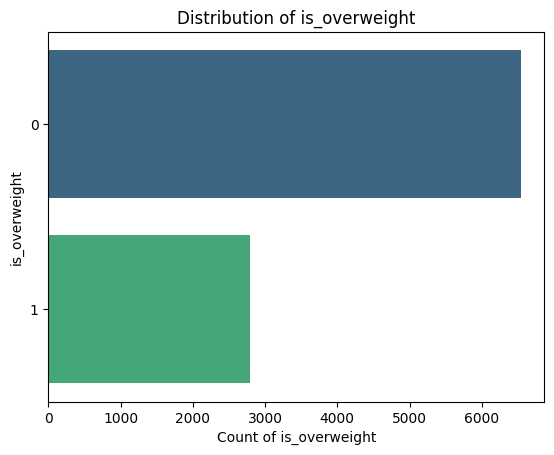

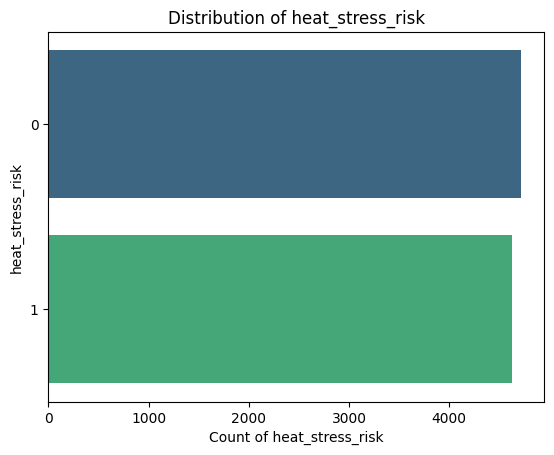

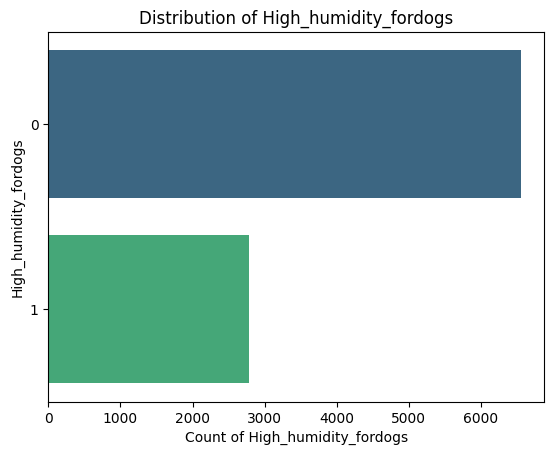

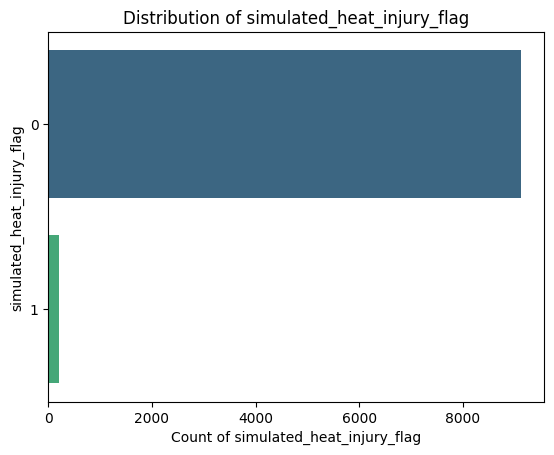

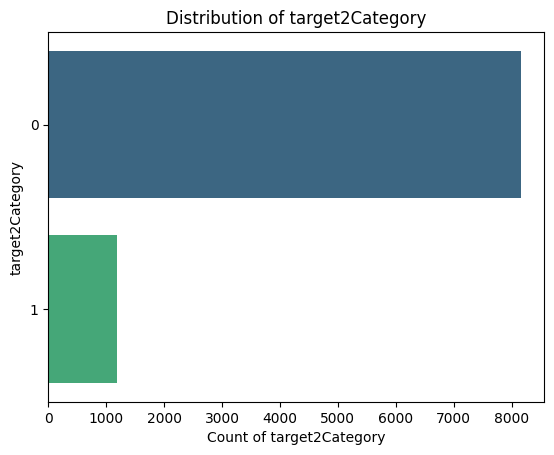

In [63]:
# visualize each boolean attribute's distribution
print("1 - true\n0 - false")
for col in bool_cols:
    top_20 = df[col].value_counts().head(20).index

    # plot details
    sns.countplot(data=df, y=col, order=top_20, palette="viridis", hue=col, hue_order=top_20, legend=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(f"Count of {col}")
    plt.ylabel(f"{col}")
    plt.show()

#### Observations
* There is a fairly even distribution of male and female dogs, with a slightly higher proportion of females
* Most dogs are not brachycephalic (flat-faced breeds with shortened snouts that can impair breathing), with approximately 1,800 classified as brachycephalic (likely including breeds such as bulldogs and pugs)
* The majority of dogs are spayed or neutered, not old, and not overweight
* Most dogs are indoors, while approximately 1,800 are outdoors, which may influence temperature-related variables
* There is an even distribution of heat stress risk (0 = normal, 1 = heat stress risk)
* Most dogs are exposed to relatively high humidity conditions
* Very few cases of heat injury are observed
* The target2category feature is somewhat unclear, but it likely represents an additional classification of heat-related outcomes or severity levels

## Feature Importance
* All attributes (disregard target variables)
* Internal attributes (biological features of dogs)
* External attributes (environmental features)

### All Features

Attributes with 0 feature impact score:
                 attr  impact_score     type
8   Playfulness Level           0.0  Numeric
9   is_brachycephalic           0.0  Boolean
11    Spayed/Neutered           0.0  Boolean
25       pct_of_ideal           0.0  Numeric
26           BCS_cont           0.0  Numeric


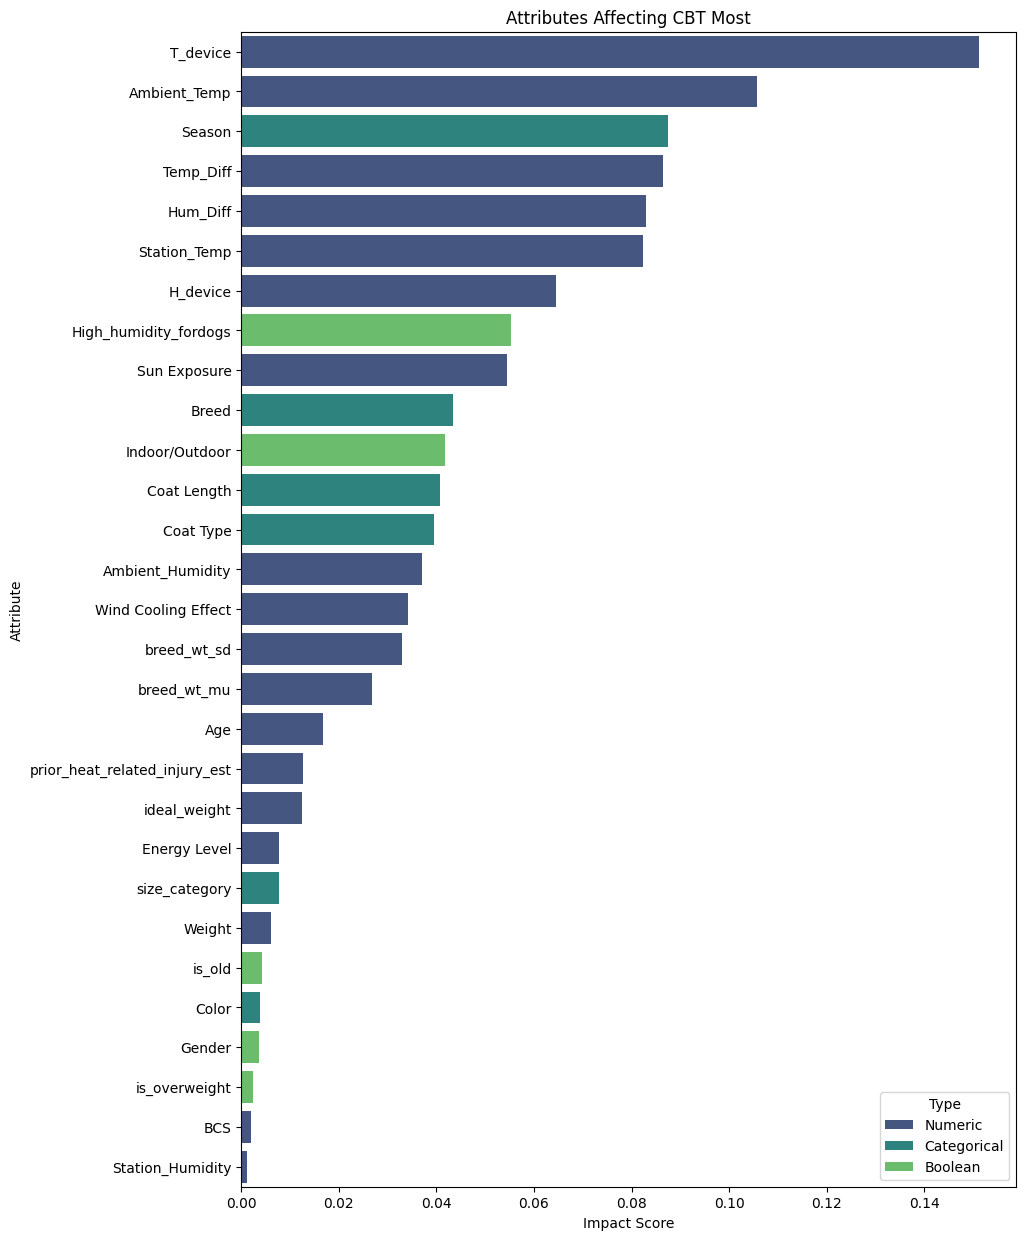

In [64]:
# target features to disregard in dataset
disregard = ["CBT_simulated", "target2Category", "target3Category", "simulated_heat_injury_flag", "heat_stress_risk"]

# split dataset into features and target variable (CBT)
attrs = df.drop(columns=disregard)
cbt = df["CBT_simulated"]

# hold metadata regarding feature type and discrete status
attr_types = []
discrete = [] # needed for mutual information calculation

# copy of features to manipulate w/o altering original data 
attr_copy = attrs.copy()

# convert non-numeric features to numbers, and identify attribute type and discrete status
for attr in attrs.columns:
    if attr in categorical_cols:
        attr_types.append("Categorical")
        discrete.append(True)
        # standardize data to strings and convert labels for mathematical processing
        attr_copy[attr] = LabelEncoder().fit_transform(attr_copy[attr].astype(str)) 
    elif attr in bool_cols: 
        attr_types.append("Boolean")
        discrete.append(True)
        # convert flags into 1/0 integers 
        attr_copy[attr] = LabelEncoder().fit_transform(attr_copy[attr])
    else:
        attr_types.append("Numeric")
        discrete.append(False)

# calculate feature importance for all features (higher score = impact CBT more)
feature_importance = mutual_info_regression(attr_copy, cbt, discrete_features=discrete, random_state=1)

# results table with attribute name, impact score, and attribute type 
results = pd.DataFrame({
    "attr": attrs.columns,
    "impact_score": feature_importance,
    "type": attr_types
})

# display attributes with 0 impact score (unrelevant features)
print("Attributes with 0 feature impact score:")
zero_score = results[results["impact_score"] == 0]
print(zero_score)

# display attributes that have a score higher than 0
results = results[results["impact_score"] > 0]
results = results.sort_values(by="impact_score", ascending=False)

# plot details
plt.figure(figsize=(10, 15))
sns.barplot(data=results, x="impact_score", y="attr", hue="type", palette="viridis", dodge=False)
plt.title("Attributes Affecting CBT Most")
plt.ylabel("Attribute")
plt.xlabel("Impact Score")
plt.legend(loc='lower right', title='Type')
plt.show()

#### Observations
* Playfulness Level, Is Brachycephalic, Spayed/Neutered, PCT of Ideal, and BCS Cont have feature impact scores of 0, indicating they do not contribute meaningfully to predicting a dog’s core body temperature (CBT)
    * Playfulness Level, Is Brachycephalic, and Spayed/Neutered likely have no impact because they do not directly influence body heat or lack sufficient variability for the model to detect patterns
    * PCT of Ideal and BCS Cont likely provide little useful signal due to extreme outliers, which add noise and make it harder to identify clear relationships with CBT
* T Device (temperature measured from the sensor) is the most influential feature (~0.14), followed by Ambient Temperature, Season, and Station Temperature (as well as related differences such as temperature and humidity differences), which contribute moderately (0.08–0.11)
* Overall, numerical features contribute most to CBT prediction, which is expected since temperature regulation is driven by measurable physical and environmental factors

### Internal Features

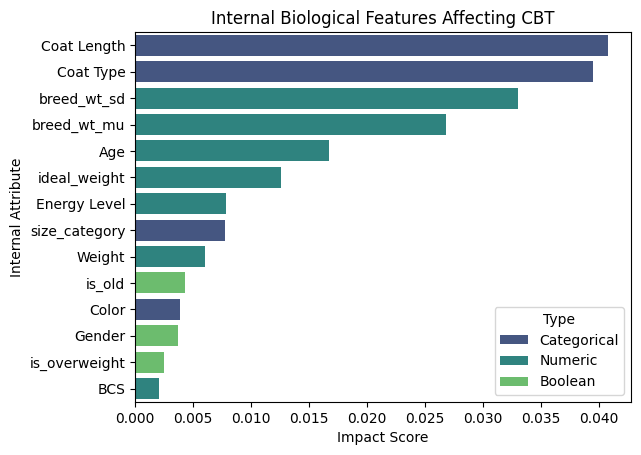

In [65]:
# list of internal biological features
internal_attrs = [
    "Age", "Weight", "Gender", "Color", "Coat Length", "Coat Type", "Energy Level", "Playfulness Level", 
    "is_brachycephalic", "size_category", "Spayed/Neutetred", "breed_wt_mu", "breed_wt_sd", "ideal_weight", 
    "pct_of_ideal", "BCS_cont", "BCS", "is_old", "is_overweight"
]

# filter results to only internal attributes
internal_results = results[results["attr"].isin(internal_attrs)]

# bar chart ranking internal features on their impact on CBT
sns.barplot(data=internal_results, x="impact_score", y="attr", hue="type", palette="viridis", dodge=False)

# plot details
plt.title("Internal Biological Features Affecting CBT")
plt.xlabel("Impact Score")
plt.ylabel("Internal Attribute")
plt.legend(loc='lower right', title='Type')
plt.show()

#### Observations
* While features were previously grouped as numerical, categorical, and boolean, they are now further categorized as internal (biological) and external (environmental) factors affecting CBT
* Among internal features, Coat Length and Coat Type contribute the most (approximately 0.04), followed by numerical features such as Breed Weight Standard Deviation, Breed Weight Mean, and Age
* BCS contributes the least, which aligns with BCS Cont having a feature impact score of 0, indicating minimal relevance to CBT prediction

### External Features

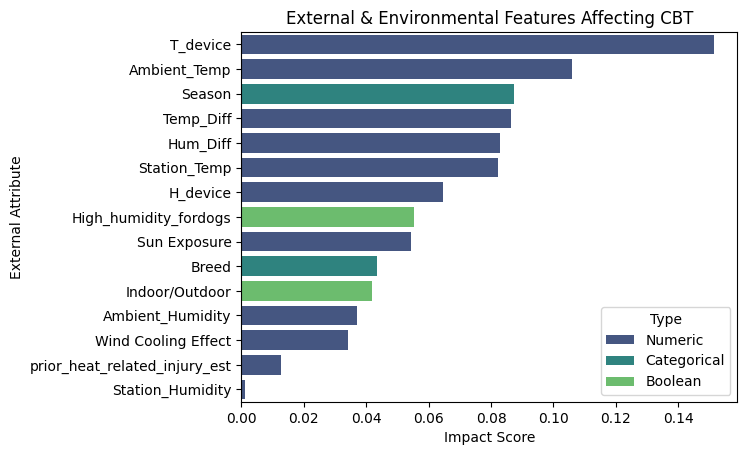

In [66]:
# list of external and environmental features
external_results = results[~results["attr"].isin(internal_attrs)]

# bar chart ranking external features on their impact on CBT
sns.barplot(data=external_results, x="impact_score", y="attr", hue="type", palette="viridis", dodge=False)

# plot details
plt.title("External & Environmental Features Affecting CBT")
plt.xlabel("Impact Score")
plt.ylabel("External Attribute")
plt.legend(loc='lower right', title='Type')
plt.show()

#### Observations
* The number of external (environmental) features is roughly equal to the number of internal (biological) features
* T Device, Ambient Temperature, and Season contribute the most, with other numerical environmental features also having moderate influence
* Station Humidity contributes the least, likely because sensor-based humidity measurements provide more accurate and relevant information for CBT prediction

## Feature Interaction 
* All features
* Only numeric features
* Catergorical and boolean features

### All Features

red - positive correlation
blue - negative correlation


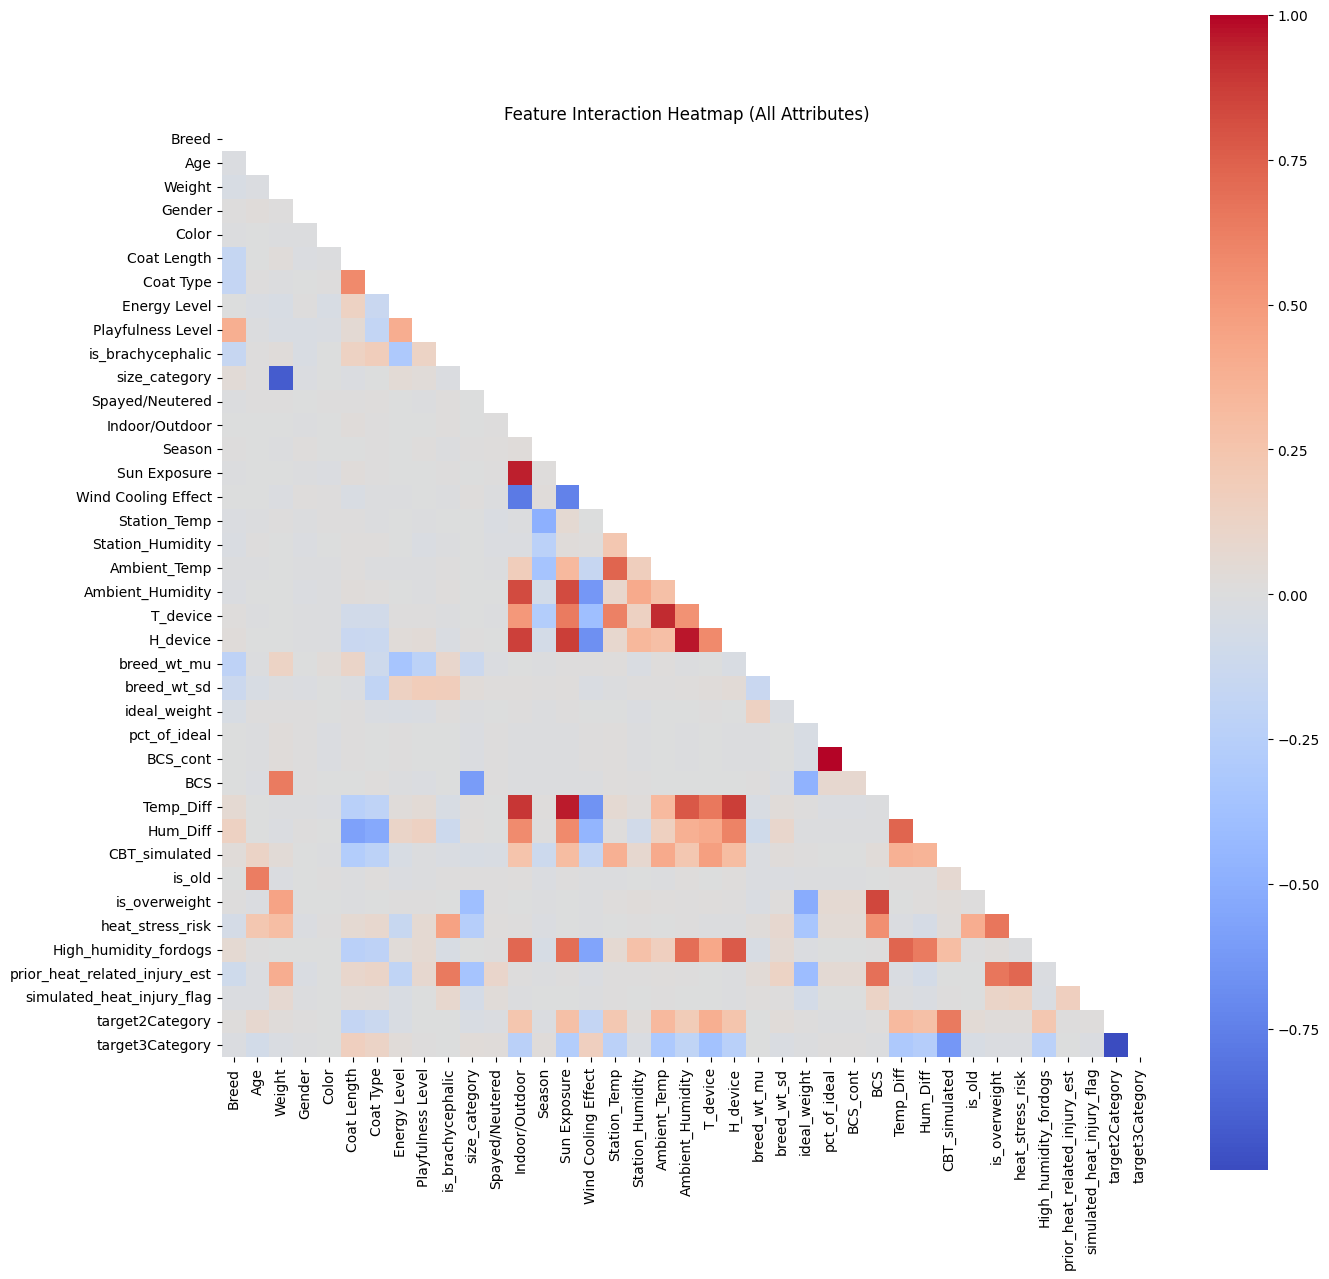

In [67]:
# copy manipulate w/o altering original data
df_all = df.copy()

# convert non-numeric features to numbers for mathematical processing
for col in df_all.columns:
    if col in categorical_cols or col in bool_cols:
        df_all[col] = LabelEncoder().fit_transform(df_all[col].astype(str))

# correlation matrix to show how all features relate to each other
corr_all = df_all.corr()

# mask to hide top half of heatmap since it's dupe info
mask = np.triu(np.ones_like(corr_all, dtype=bool))

# color-coded heatmap to vizualize all relationships strenghts
plt.figure(figsize=(15, 15))
sns.heatmap(corr_all, mask=mask, annot=False, fmt=".2f", cmap="coolwarm", square=True)

# plot details
plt.title("Feature Interaction Heatmap (All Attributes)")
print("red - positive correlation\nblue - negative correlation")
plt.show()

#### Observations
* Feature interactions help identify how different features relate to and influence one another
* There are more strong positive correlations than negative correlations overall
* Positive correlation means that as one feature increases, the other also tends to increase, while negative correlation means that as one feature increases, the other tends to decrease
* Some features may show misleading correlations due to the encoding of categorical and boolean variables (by label encoding), where assigned numeric values can distort relationships and potentially reverse the direction of correlation
* Strong negative correlations are observed between pairs such as target2Category vs. target3Category, Wind Cooling Effect vs. Indoor/Outdoor, and Wind Cooling Effect vs. Sun Exposure
* Size vs. Weight appears as a negative correlation due to noise in the data (e.g., negative weight values), which misleads the model into suggesting that larger size corresponds to lower weight, contradicting biological expectations
* Strong positive correlations are observed between Sun Exposure vs. Indoor/Outdoor, Temperature Difference vs. Indoor/Outdoor, Temperature Difference vs. Sun Exposure, H Device vs. Ambient Humidity, T Device vs. Ambient Temperature, and BCS Cont vs. PCT of Ideal

### Numeric Feautres

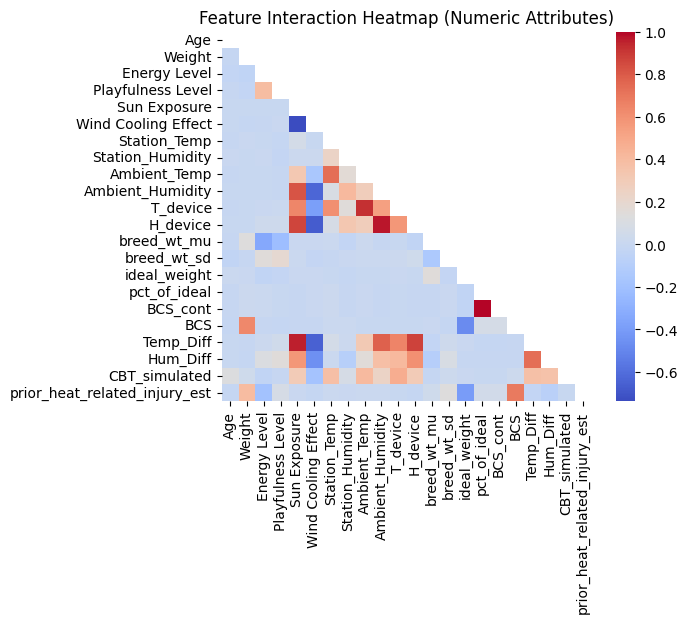

In [68]:
# correlation matrix for numeric features
corr_numeric = df[numeric_cols].corr()

# mask dupe info
mask = np.triu(np.ones_like(corr_numeric, dtype=bool))

# heatmap to visualize numerical relationship strengths
sns.heatmap(corr_numeric, mask=mask, annot=False, fmt=".2f", cmap="coolwarm", square=True)

# plot details
plt.title("Feature Interaction Heatmap (Numeric Attributes)")
plt.show()

#### Observations
* Many numerical features show negative correlations, likely due to inverse relationships between environmental factors (e.g., cooling effects vs. heat exposure)
* Strong negative correlations are observed between Wind Cooling Effect vs. Sun Exposure, Ambient Temperature vs. Wind Cooling Effect, H Device vs. Wind Cooling Effect, and Temperature Difference vs. Wind Cooling Effect
* Strong positive correlations are observed between Temperature Difference vs. Sun Exposure, T Device vs. Ambient Temperature, H Device vs. Ambient Humidity, and BCS Cont vs. PCT of Ideal

### Categorical and Boolean Features

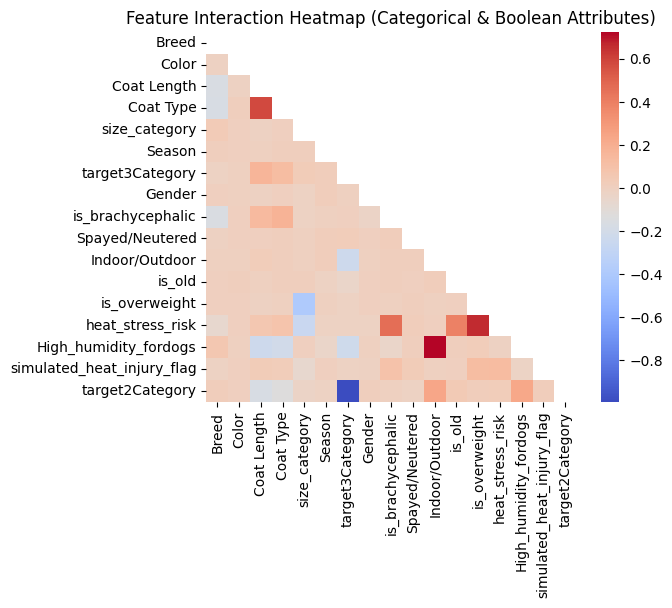

In [69]:
# combined list of categorical and boolean attributes
target_cols = categorical_cols + bool_cols

# copy of only categorical and boolean attributes 
df_target = df[target_cols].copy()

# convert non-numeric features to numbers for mathematical processing
for col in df_target.columns:
    df_target[col] = LabelEncoder().fit_transform(df_target[col].astype(str))

# correlation matrix for categorical and boolean features
corr_target = df_target.corr()

# mask dupe info
mask = np.triu(np.ones_like(corr_target, dtype=bool))

# heatmap to vizualize categorical and boolean relationship strengths
sns.heatmap(corr_target, mask=mask, annot=False, fmt=".2f", cmap="coolwarm", square=True)

# plot details
plt.title("Feature Interaction Heatmap (Categorical & Boolean Attributes)")
plt.show()

#### Observations
* Many categorical and boolean features show positive correlations, likely due to shared characteristics or overlapping group definitions
* Strong positive correlations are observed between Coat Type vs. Coat Length, Heat Stress Risk vs. Is Brachycephalic, High Humidity for Dogs vs. Indoor/Outdoor, and Heat Stress Risk vs. Is Overweight
* A strong negative correlation is observed between target2Category and target3Category, however, this is expected since they represent the same outcome using different encoding methods (binary vs. multi-class labels)

## Univariate Analysis
* Explore individual attributes to understand their statistical distributions, patterns, and typical value ranges
* Identify which specific feature values have the strongest correlation or predictive power regarding the target attributes
* Key focus areas:
   * Main target feature: CBT_simulated
   * Risk classification features: target2Category, target3Category, simulated_heat_injury_flag, heat_stress_risk
   * High-impact features: coat length, coat type, T_device, ambient_temp

### Target Feature
* Calculate summary statistics for CBT_simulated to identify the mean, variance, and range
* Visualize the distribution of CBT_simulated to detect skewness or outliers
* Univariate feature selection - rank the predictive power of features against CBT_simulated
   * Incorporate all attribute types in the scoring process (numeric, categorical, bool)
   * Ignore redundant attributes that do not contribute to heat stress (ex: target2Category)

Statistical Summary of CBT:
count    9335.0000
mean       39.1300
std         0.5830
min        37.5000
25%        38.7227
50%        39.1134
75%        39.5207
max        41.3628


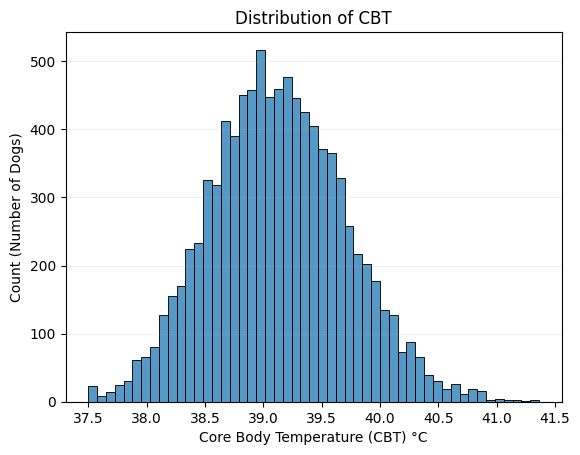

In [70]:
# statistical summary of CBT
print("Statistical Summary of CBT:")
print(df["CBT_simulated"].describe().round(4).to_string(name=False, dtype=False))

# histplot to show distribution of CBT
sns.histplot(df["CBT_simulated"])

# plot details
plt.title("Distribution of CBT")
plt.ylabel("Count (Number of Dogs)")
plt.xlabel("Core Body Temperature (CBT) °C")
plt.grid(axis="y", alpha=0.2)
plt.show()

#### Observations
* Core Body Temperature (CBT) follows a normal (bell-shaped) distribution
* CBT values are typically around 39.0 °C, which is consistent with the expected real body temperature range of approximately 37–39 °C

In [71]:
# converts categorical cols to numbers so scoring can work
df_encoded = pd.get_dummies(df)

# get numeric and bool cols (categorical have been converted to bool)
feature_cols = df_encoded.select_dtypes(include=["number", "bool"]).columns

# define features (x) and target (y) and ignore certain attributes
x = df_encoded[feature_cols].drop(columns=["CBT_simulated", "target2Category", "target3Category_Normal", 
                                           "target3Category_Heat Stress", "target3Category_Heat Stroke"])
y = df_encoded["CBT_simulated"]

# get top 15 highest scoring features
top_features = SelectKBest(score_func=f_regression, k=15) # regression since CBT is numeric
top_features.fit(x, y)

# display features and their respective f-score
feature_scores = pd.DataFrame({
    "Feature": x.columns,
    "Score": top_features.scores_.round(4)
})

# show first 15 results in descending order
print("Univariate analysis for CBT_simulated:")
feature_scores.sort_values(by="Score", ascending=False).head(15).reset_index(drop=True)

Univariate analysis for CBT_simulated:


,Feature,Score
0,T_device,2717.7998
1,Ambient_Temp,1867.3467
2,Station_Temp,1548.8226
3,Temp_Diff,1496.4686
4,Hum_Diff,1376.3141
5,Season_Summer,1254.9740
6,Season_Winter,1081.6759
7,Sun Exposure,947.4900
8,H_device,935.2506
9,High_humidity_fordogs,869.2518


#### Observations
* T Device, Ambient Temperature, and Station Temperature are strong predictors of CBT based on univariate analysis, which aligns with previous findings

### Risk Classification Features
* Calculate summary statistics for risk classification attributes to identify the mean, variance, and range
* Visualize the distribution of attributes to detect skewness or outliers
* Univariate feature selection - rank the predictive power of features against the attributes
   * Incorporate all attribute types in the scoring process (numeric, categorical, bool)
   * Ignore redundant attributes that do not contribute to heat stress (ex: target2Category)

#### target2Category

In [72]:
# converts categorical cols to numbers so scoring can work
df_encoded = pd.get_dummies(df)

# get numeric and bool cols (categorical have been converted to bool)
feature_cols = df_encoded.select_dtypes(include=["number", "bool"]).columns

# define features (x) and target (y) and ignore certain attributes
x = df_encoded[feature_cols].drop(columns=["CBT_simulated", "target2Category", "target3Category_Normal", 
                                           "target3Category_Heat Stress", "target3Category_Heat Stroke"])
y = df["target2Category"]

# get top 15 highest scoring features
top_features = SelectKBest(score_func=f_classif, k=15) # classification since target2Category is boolean
top_features.fit(x, y)

# display features and their respective f-score
feature_scores = pd.DataFrame({
    "Feature": x.columns,
    "Score": top_features.scores_.round(4)
})

# show first 15 results in descending order
print("Univariate analysis for target2Category:")
feature_scores.sort_values(by="Score", ascending=False).head(15).reset_index(drop=True)

Univariate analysis for target2Category:


,Feature,Score
0,T_device,1626.1072
1,Ambient_Temp,1085.4703
2,Temp_Diff,1051.9022
3,Sun Exposure,796.0614
4,Hum_Diff,777.2226
5,Season_Summer,633.6594
6,H_device,601.2721
7,Indoor/Outdoor_Outdoor_Now,569.5159
8,Indoor/Outdoor_Indoor_Now,569.5159
9,High_humidity_fordogs,534.9207


#### target3Category

Statistical Summary of target3Category:
count       9335
unique         3
top       Normal
freq        8151


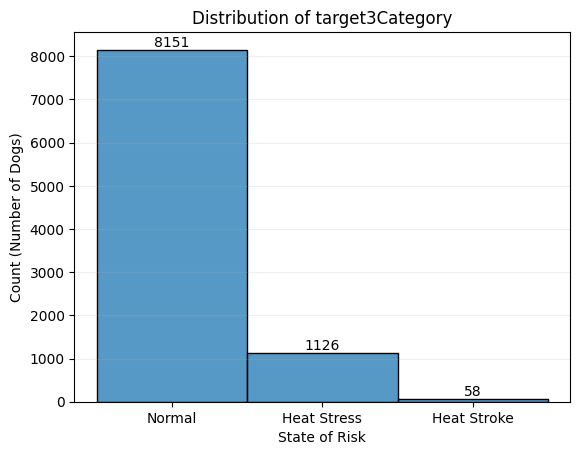

In [73]:
# statistical summary of target3Category
print("Statistical Summary of target3Category:")
print(df["target3Category"].describe().to_string(name=False, dtype=False))

# histplot to show distribution of target3Category
plot = sns.histplot(df["target3Category"])
plot.bar_label(plot.containers[0]) # display count above bars

# plot details
plt.title("Distribution of target3Category")
plt.ylabel("Count (Number of Dogs)")
plt.xlabel("State of Risk")
plt.grid(axis="y", alpha=0.2)
plt.show()

#### Observations
* Most dogs are in a normal state, with 1,125 experiencing heat stress and 58 experiencing heat stroke

In [74]:
# converts categorical cols to numbers so scoring can work
df_encoded = pd.get_dummies(df)

# get numeric and bool cols (categorical have been converted to bool)
feature_cols = df_encoded.select_dtypes(include=["number", "bool"]).columns

# define features (x) and target (y)
x = df_encoded[feature_cols].drop(columns=["CBT_simulated", "target2Category", "target3Category_Normal", 
                                           "target3Category_Heat Stress", "target3Category_Heat Stroke"])
y = df["target3Category"]

# get top 15 highest scoring features
top_features = SelectKBest(score_func=f_classif, k=15) # classification since target3Category has labels
top_features.fit(x, y)

# display features and their respective f-score
feature_scores = pd.DataFrame({
    "Feature": x.columns,
    "Score": top_features.scores_.round(4)
})

# show first 15 results in descending order
print("Univariate analysis for target3Category:")
feature_scores.sort_values(by="Score", ascending=False).head(15).reset_index(drop=True)

Univariate analysis for target3Category:


,Feature,Score
0,T_device,884.3598
1,Ambient_Temp,588.5558
2,Temp_Diff,567.9802
3,Sun Exposure,426.1607
4,Hum_Diff,417.1265
5,Season_Summer,329.1563
6,H_device,311.2827
7,Indoor/Outdoor_Outdoor_Now,299.4663
8,Indoor/Outdoor_Indoor_Now,299.4663
9,High_humidity_fordogs,277.6200


#### simulated_heat_injury_flag

In [75]:
# converts categorical cols to numbers so scoring can work
df_encoded = pd.get_dummies(df)

# get numeric and bool cols (categorical have been converted to bool)
feature_cols = df_encoded.select_dtypes(include=["number", "bool"]).columns

# define features (x) and target (y)
x = df_encoded[feature_cols].drop(columns=["CBT_simulated", "target2Category", "target3Category_Normal", 
                                           "target3Category_Heat Stress", "target3Category_Heat Stroke", "simulated_heat_injury_flag"])
y = df["simulated_heat_injury_flag"]

# get top 15 highest scoring features
top_features = SelectKBest(score_func=f_classif, k=15) # classification since simulated_heat_injury_flag is boolean
top_features.fit(x, y)

# display features and their respective f-score
feature_scores = pd.DataFrame({
    "Feature": x.columns,
    "Score": top_features.scores_.round(4)
})

# show first 15 results in descending order
print("Univariate analysis for simulated_heat_injury_flag:")
feature_scores.sort_values(by="Score", ascending=False).head(15).reset_index(drop=True)

Univariate analysis for simulated_heat_injury_flag:


,Feature,Score
0,prior_heat_related_injury_est,243.1565
1,heat_stress_risk,156.2890
2,BCS,146.6247
3,is_overweight,136.8289
4,is_brachycephalic,71.6062
5,ideal_weight,51.0179
6,Weight,44.7440
7,size_category_Giant,31.6073
8,Coat Type_Wavy,17.5205
9,Breed_Cavalier King Charles Spaniel,17.5205


#### heat_stress_risk

In [76]:
# converts categorical cols to numbers so scoring can work
df_encoded = pd.get_dummies(df)

# get numeric and bool cols (categorical have been converted to bool)
feature_cols = df_encoded.select_dtypes(include=["number", "bool"]).columns

# define features (x) and target (y)
x = df_encoded[feature_cols].drop(columns=["CBT_simulated", "target2Category", "target3Category_Normal", 
                                           "target3Category_Heat Stress", "target3Category_Heat Stroke", "simulated_heat_injury_flag", 
                                           "heat_stress_risk"])
y = df["heat_stress_risk"]

# get top 15 highest scoring features
top_features = SelectKBest(score_func=f_classif, k=15) # classification since heat_stress_risk is boolean
top_features.fit(x, y)

# display features and their respective f-score
feature_scores = pd.DataFrame({
    "Feature": x.columns,
    "Score": top_features.scores_.round(4)
})

# show first 15 results in descending order
print("Univariate analysis for heat_stress_risk:")
feature_scores.sort_values(by="Score", ascending=False).head(15).reset_index(drop=True)

Univariate analysis for heat_stress_risk:


,Feature,Score
0,prior_heat_related_injury_est,10310.9117
1,is_overweight,7221.6092
2,BCS,4070.1670
3,is_brachycephalic,2482.8624
4,is_old,1702.9785
5,ideal_weight,1165.3626
6,Weight,917.1467
7,size_category_Giant,538.2647
8,Age,538.1249
9,Breed_Pekingese,246.7572


#### Observations
* A dog’s history of previous heat-related injury is the strongest predictor of its risk of heat stress, which is expected since prior injury may increase susceptibility to future heat-related issues

### High-Impact Features
* Calculate summary statistics for high-impact features to identify the mean, variance, and range
* Visualize the distribution of attributes to detect skewness or outliers
* Univariate feature selection - rank the predictive power of features against the attributes
   * Select the top two highest-impact features from both the categorical and numerical attributes list
      * Could do more, choosing two for now
   * Incorporate all attribute types in the scoring process (numeric, categorical, bool)
   * Ignore redundant attributes that do not contribute to heat stress (ex: target2Category)

#### Coat Length

Statistical Summary of Coat Length:
count      9335
unique        3
top       Short
freq       5087


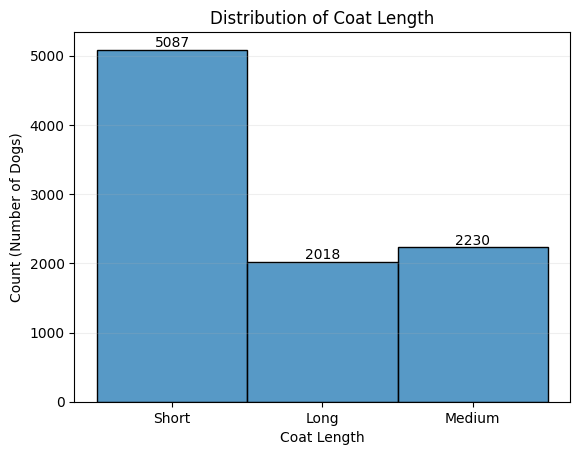

In [77]:
# statistical summary of coat length
print("Statistical Summary of Coat Length:")
print(df["Coat Length"].describe().to_string(name=False, dtype=False))

# histplot to show distribution of coat length
plot = sns.histplot(df["Coat Length"])
plot.bar_label(plot.containers[0]) # display count above bars

# plot details
plt.title("Distribution of Coat Length")
plt.ylabel("Count (Number of Dogs)")
plt.xlabel("Coat Length")
plt.grid(axis="y", alpha=0.2)
plt.show()

#### Observations
* Most dogs have short coat lengths, with approximately 2,018 having long coats and 2,230 having medium coats

In [78]:
# converts categorical cols to numbers so scoring can work
df_encoded = pd.get_dummies(df)

# get numeric and bool cols (categorical have been converted to bool)
feature_cols = df_encoded.select_dtypes(include=["number", "bool"]).columns

# define features (x) and target (y)
x = df_encoded[feature_cols].drop(columns=[
    "CBT_simulated", "target2Category", "target3Category_Normal", "target3Category_Heat Stress", 
    "target3Category_Heat Stroke", "simulated_heat_injury_flag", "heat_stress_risk", "Coat Length_Short", 
    "Coat Length_Medium", "Coat Length_Long", "Coat Type_Smooth", "Coat Type_Double", "Coat Type_Silky", 
    "Coat Type_Curly", "Coat Type_Wavy"])
y = df["Coat Length"]

# get top 15 highest scoring features
top_features = SelectKBest(score_func=f_classif, k=15) # classification since coat length has labels
top_features.fit(x, y)

# display features and their respective f-score
feature_scores = pd.DataFrame({
    "Feature": x.columns,
    "Score": top_features.scores_.round(4)
})

# show first 15 results in descending order
print("Univariate analysis for Coat Length:")
feature_scores.sort_values(by="Score", ascending=False).head(15).reset_index(drop=True)

Univariate analysis for Coat Length:


,Feature,Score
0,Hum_Diff,2389.8712
1,Breed_Pekingese,470.4612
2,Breed_Poodle,440.6659
3,Breed_Cocker Spaniel,422.5433
4,Breed_Cavalier King Charles Spaniel,375.0319
5,Breed_Samoyed,360.3569
6,Breed_Yorkshire Terrier,358.1710
7,Breed_Havanese,351.6276
8,Breed_Maltese,338.6045
9,Breed_Alaskan Malamute,328.8617


#### Observations
* Humidity levels appear to be a strong predictor of a dog’s coat length
* Specific dog breeds also help predict coat length, which aligns with realistic expectations
   * Breeds such as Pekingese, Poodle, and Spaniel show strong associations

#### Coat Type

Statistical Summary of Coat Type:
count       9335
unique         6
top       Smooth
freq        4289


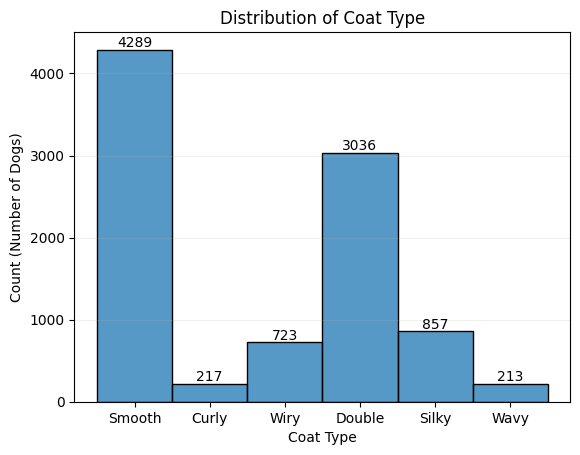

In [79]:
# statistical summary of coat type
print("Statistical Summary of Coat Type:")
print(df["Coat Type"].describe().to_string(name=False, dtype=False))

# histplot to show distribution of coat type
plot = sns.histplot(df["Coat Type"])
plot.bar_label(plot.containers[0]) # display count above bars

# plot details
plt.title("Distribution of Coat Type")
plt.ylabel("Count (Number of Dogs)")
plt.xlabel("Coat Type")
plt.grid(axis="y", alpha=0.2)
plt.show()

#### Observations
* Most dogs have smooth or double coat types, while fewer than 900 dogs have curly, wiry, silky, or wavy coats

In [80]:
# converts categorical cols to numbers so scoring can work
df_encoded = pd.get_dummies(df)

# get numeric and bool cols (categorical have been converted to bool)
feature_cols = df_encoded.select_dtypes(include=["number", "bool"]).columns

# define features (x) and target (y)
x = df_encoded[feature_cols].drop(columns=[
    "CBT_simulated", "target2Category", "target3Category_Normal", "target3Category_Heat Stress", 
    "target3Category_Heat Stroke", "simulated_heat_injury_flag", "heat_stress_risk",
    "Coat Type_Wiry", "Coat Type_Wavy", "Coat Type_Smooth", "Coat Type_Silky", "Coat Type_Double", "Coat Type_Curly",
    "Breed_Poodle", "Breed_Cavalier King Charles Spaniel"])
y = df["Coat Type"]

# get top 15 highest scoring features
top_features = SelectKBest(score_func=f_classif, k=15) # classifcation since coat type has labels
top_features.fit(x, y)

# display features and their respective f-score
feature_scores = pd.DataFrame({
    "Feature": x.columns,
    "Score": top_features.scores_.round(4)
})

# show first 15 results in descending order
print("Univariate analysis for Coat Type:")
feature_scores.sort_values(by="Score", ascending=False).head(15).reset_index(drop=True)

Univariate analysis for Coat Type:


,Feature,Score
0,Coat Length_Short,5990.1899
1,Coat Length_Long,1644.8822
2,Hum_Diff,1098.6199
3,Coat Length_Medium,1079.6186
4,Breed_Jack Russell Terrier,613.5941
5,Breed_Miniature Schnauzer,562.1837
6,Breed_Airedale Terrier,562.1837
7,Breed_Chesapeake Bay Retriever,558.0016
8,is_brachycephalic,472.6926
9,Breed_Yorkshire Terrier,450.5345


#### Observations
* Coat Length, Humidity, and Breed Type are strong predictors of coat type
* The strong relationship between short or long coat length and coat type is expected, as coat length directly relates to how coat types are classified 

#### T_device

Statistical Summary of T_device:
count    9335.000000
mean       26.919589
std         5.924103
min         4.170000
25%        24.050000
50%        26.030000
75%        27.580000
max        59.090000


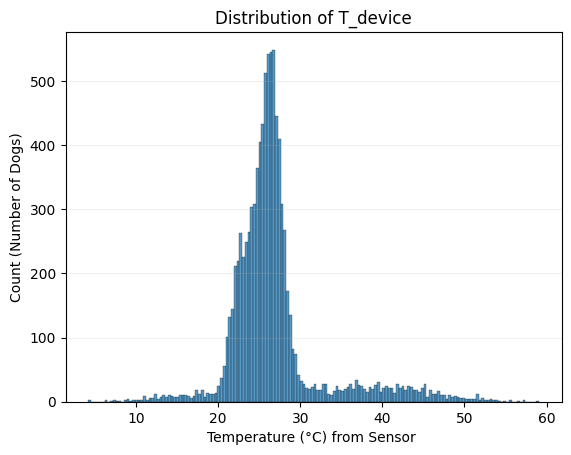

In [81]:
# statistical summary of T_device
print("Statistical Summary of T_device:")
print(df["T_device"].describe().to_string(name=False, dtype=False))

# histplot to show distribution of T_device
sns.histplot(df["T_device"])

# plot details
plt.title("Distribution of T_device")
plt.ylabel("Count (Number of Dogs)")
plt.xlabel("Temperature (°C) from Sensor ")
plt.grid(axis="y", alpha=0.2)
plt.show()

#### Observations
* T Device follows a normal distribution
* The typical temperature recorded by the sensor is around 26 °C

In [82]:
# converts categorical cols to numbers so scoring can work
df_encoded = pd.get_dummies(df)

# get numeric and bool cols (categorical have been converted to bool)
feature_cols = df_encoded.select_dtypes(include=["number", "bool"]).columns

# define features (x) and target (y)
x = df_encoded[feature_cols].drop(columns=[
    "CBT_simulated", "target2Category", "target3Category_Normal", "target3Category_Heat Stress", 
    "target3Category_Heat Stroke", "simulated_heat_injury_flag", "heat_stress_risk", "T_device"])
y = df_encoded["T_device"]

# get top 15 highest scoring features
top_features = SelectKBest(score_func=f_regression, k=15) # regression since T_device is numbers
top_features.fit(x, y)

# display features and their respective f-score
feature_scores = pd.DataFrame({
    "Feature": x.columns,
    "Score": top_features.scores_.round(4)
})

# show first 15 results in descending order
print("Univariate analysis for T_device:")
feature_scores.sort_values(by="Score", ascending=False).head(15).reset_index(drop=True)

Univariate analysis for T_device:


,Feature,Score
0,Ambient_Temp,55152.8163
1,Temp_Diff,6952.8996
2,Sun Exposure,6502.9665
3,Station_Temp,5566.0531
4,H_device,4684.2627
5,Ambient_Humidity,3783.8406
6,Indoor/Outdoor_Indoor_Now,3140.4325
7,Indoor/Outdoor_Outdoor_Now,3140.4325
8,Season_Winter,2863.9229
9,High_humidity_fordogs,2044.2064


#### Observations
* Temperature from the sensor (T Device) is primarily predicted by Ambient Temperature, Sun Exposure, and Station Temperature

#### Ambient_Temp

Statistical Summary of Ambient_Temp:
count    9335.000000
mean       23.020484
std         4.727298
min        -2.070000
25%        21.000000
50%        23.080000
75%        24.400000
max        49.420000


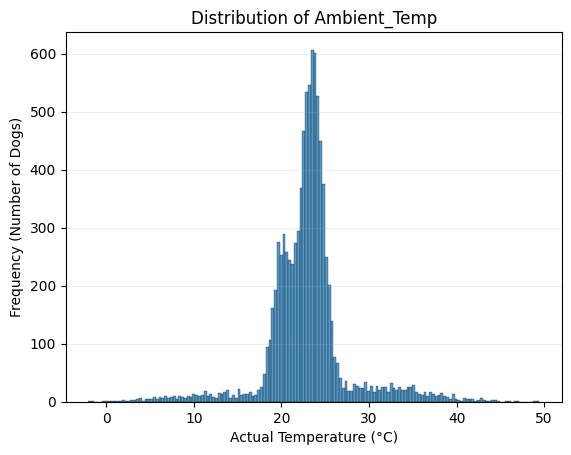

In [83]:
# statistical summary of Ambient_temp
print("Statistical Summary of Ambient_Temp:")
print(df["Ambient_Temp"].describe().to_string(name=False, dtype=False))

# histplot to show distribution of Ambient_temp
sns.histplot(df["Ambient_Temp"])

# plot details
plt.title("Distribution of Ambient_Temp")
plt.ylabel("Frequency (Number of Dogs)")
plt.xlabel("Actual Temperature (°C)")
plt.grid(axis="y", alpha=0.2)
plt.show()

#### Observations
* Ambient Temperature follows a normal distribution, with typical values around 23 °C

In [84]:
# converts categorical cols to numbers so scoring can work
df_encoded = pd.get_dummies(df)

# get numeric and bool cols (categorical have been converted to bool)
feature_cols = df_encoded.select_dtypes(include=["number", "bool"]).columns

# define features (x) and target (y)
x = df_encoded[feature_cols].drop(columns=[
    "CBT_simulated", "target2Category", "target3Category_Normal", "target3Category_Heat Stress", 
    "target3Category_Heat Stroke", "simulated_heat_injury_flag", "heat_stress_risk", "Ambient_Temp"])
y = df_encoded["Ambient_Temp"]

# get top 15 highest scoring features
top_features = SelectKBest(score_func=f_regression, k=15) # regression since Ambient_Temp is numeric
top_features.fit(x, y)

# display features and their respective f-score
feature_scores = pd.DataFrame({
    "Feature": x.columns,
    "Score": top_features.scores_.round(4)
})

# show first 15 results in descending order
print("Univariate analysis for Ambient_Temp:")
feature_scores.sort_values(by="Score", ascending=False).head(15).reset_index(drop=True)

Univariate analysis for Ambient_Temp:


,Feature,Score
0,T_device,55152.8163
1,Station_Temp,10866.3018
2,Season_Winter,4527.8167
3,Season_Summer,1431.1771
4,Sun Exposure,1092.9718
5,Temp_Diff,1037.3301
6,H_device,823.8882
7,Ambient_Humidity,801.5387
8,Indoor/Outdoor_Outdoor_Now,311.1443
9,Indoor/Outdoor_Indoor_Now,311.1443


#### Observations
* Ambient Temperature is strongly predicted by T Device, Station Temperature, and Season factors such as winter and summer

## Summary
* Core Body Temperature (CBT) is most strongly influenced by T Device, Ambient Temperature, and Station Temperature, with additional contributions from environmental differences (e.g., temperature and humidity differences) and seasonal factors
* Numerical features provide the most predictive power overall, while categorical and boolean features contribute less, with several showing minimal or no impact
   * Features can also be grouped into internal (biological) and external (environmental) factors, with both groups contributing relatively equally, though environmental factors tend to have stronger direct effects on CBT
* Several features show little to no predictive value (e.g., Playfulness Level, Spayed/Neutered, PCT of Ideal, BCS Cont), often due to lack of variability or the presence of extreme outliers
* Strong feature interactions observed:
   * Positive correlations (move together): T Device vs. Ambient Temperature, H Device vs. Ambient Humidity, BCS Cont vs. PCT of Ideal
   * Negative correlations (move oppositely): Wind Cooling Effect vs Sun Exposure, H Device vs. Wind Cooling Effect
* The dataset is generally realistic in structure (e.g., normal distributions for CBT and temperature), but contains some unrealistic values and extreme outliers (especially in PCT of Ideal and BCS Cont) due to simulation methods
   * Data cleaning (e.g., flooring values or applying thresholds) is necessary to improve model reliability
* Overall, environmental and temperature-related variables dominate CBT prediction, which aligns with real-world expectations, while biological and categorical traits play a secondary role